# INX Future Inc  Employee Performance Analysis
---
### IABAC Data Science Project
Prepared by Janeth


This project focuses on developing an employee performance prediction model using machine learning techniques and algorithms to identify patterns and trends within employee data. The model is designed to predict employee performance based on key workplace, demographic, and professional factors. The primary goal is to assist Human Resource (HR) departments in making informed decisions regarding employee evaluation, recruitment, workforce planning, and overall organizational productivity

**Approach used**
* Project Objective
* Importing Libraries
* Load Dataset
* Exploratory Data Anlysis
* Preprocessing
* Splitting Dataset
* Train Model
* Building Model and Evaluation
* Saving Model and deploy
* General Overview and Recommendation

## 1. Project Objective

**Overview**

INX Future Inc. is a leading data analytics and automation solutions company with over 15 years of global experience and a strong reputation as one of the industry's best employers. Despite its employee friendly HR policies, the company has recently experienced a decline in employee performance, resulting in increased service delivery issues and an 8% drop in client satisfaction levels. To address these challenges, the CEO initiated a data science project to analyze employee data, identify the root causes of performance issues, and gain insights that can support effective decision-making without negatively affecting employee morale or the company's employer brand.

**Objective**

The primary objective of this project is to analyze employee performance data and develop a machine learning based prediction model to identify factors that influence employee performance. The project aims to conduct..

 1. Department-wise performance analysis
 2. Determine the most important factors affecting performance
 3. Build a predictive model that can forecast employee performance based on employee and workplace attributes. 
 
 Additionally, the project seeks to provide actionable recommendations that support Human Resource Management in improving employee evaluation, recruitment, workforce planning, and overall organizational productivity

## 2. Importing Libraries

In [106]:
# importing libraries
import numpy as np # for numerical operations
import pandas as pd # for data manipulation and analysis
import matplotlib.pyplot as plt # for data visualization
import seaborn as sns # for statistical data visualization
from sklearn.model_selection import train_test_split # for splitting data into training and testing sets
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier # for ensemble learning and improving model performance
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix # for evaluating model performance
import xgboost as xgb # for gradient boosting classification modeling  
from imblearn.over_sampling import SMOTE # for handling imbalanced datasets     
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder # for encoding categorical variables
import openpyxl
import joblib
print(openpyxl.__version__)
print("Libraries imported successfully")



3.1.5
Libraries imported successfully


## 3. Load dataset
The dataset was imported from an Excel file into a **pandas DataFrame**, providing a structured and efficient format for data manipulation, analysis, preprocessing, and machine learning tasks throughout the project.


In [107]:
# loading the dataset
df = pd.read_excel("INX_Future_Inc_Employee_Performance_dataset.xlsx")

In [108]:
# displaying the first few rows of the dataset to understand its structure and contents
df.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3


The df.head gives an overview of the first five rows, peeking at our data's structure, column names, and values 

## 4. Exploratory data Analysis ( EDA)

It is the process of examining and summarizing a dataset to understand its main characteristics before doing any formal modeling or analysis.

It  typically involves:
* Understanding the structure — shape, column names, data types (df.info(), df.shape)
* Summary statistics — mean, median, min, max, std (df.describe())
* Checking for missing values — (df.isnull().sum())
* Distributions — histograms, box plots to see how values are spread
* Relationships — correlations between columns, scatter plots
* Spotting outliers — values that seem unusually high or low
* Checking for duplicates — (df.duplicated().sum())

In [109]:
# information about dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   EmpNumber                     1200 non-null   str  
 1   Age                           1200 non-null   int64
 2   Gender                        1200 non-null   str  
 3   EducationBackground           1200 non-null   str  
 4   MaritalStatus                 1200 non-null   str  
 5   EmpDepartment                 1200 non-null   str  
 6   EmpJobRole                    1200 non-null   str  
 7   BusinessTravelFrequency       1200 non-null   str  
 8   DistanceFromHome              1200 non-null   int64
 9   EmpEducationLevel             1200 non-null   int64
 10  EmpEnvironmentSatisfaction    1200 non-null   int64
 11  EmpHourlyRate                 1200 non-null   int64
 12  EmpJobInvolvement             1200 non-null   int64
 13  EmpJobLevel                   1200 non-null 

 We have 1,200 entries in the dataset with 28 features with no missing values .All 1,200 entries are non-null across every column.
 On data types we have 19 numeric columns (int64) and 9 string/categorical columns 


In [110]:
# describe the dataset to get statistical summary of numerical columns
df.describe()

,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,36.918333,9.165833,2.89250,2.715833,65.981667,2.731667,2.067500,2.732500,2.665000,15.222500,2.725000,11.330000,2.785833,2.744167,7.077500,4.291667,2.194167,4.105000,2.948333
std,9.087289,8.176636,1.04412,1.090599,20.211302,0.707164,1.107836,1.100888,2.469384,3.625918,1.075642,7.797228,1.263446,0.699374,6.236899,3.613744,3.221560,3.541576,0.518866
min,18.000000,1.000000,1.00000,1.000000,30.000000,1.000000,1.000000,1.000000,0.000000,11.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,30.000000,2.000000,2.00000,2.000000,48.000000,2.000000,1.000000,2.000000,1.000000,12.000000,2.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,3.000000
50%,36.000000,7.000000,3.00000,3.000000,66.000000,3.000000,2.000000,3.000000,2.000000,14.000000,3.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,3.000000
75%,43.000000,14.000000,4.00000,4.000000,83.000000,3.000000,3.000000,4.000000,4.000000,18.000000,4.000000,15.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000,3.000000
max,60.000000,29.000000,5.00000,4.000000,100.000000,4.000000,5.000000,4.000000,9.000000,25.000000,4.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000,4.000000


In [111]:
# converting specific columns to 'object' data type for categorical analysis
columns_to_convert = ['EmpEducationLevel','EmpEnvironmentSatisfaction','EmpJobInvolvement','EmpJobSatisfaction','PerformanceRating','EmpRelationshipSatisfaction','EmpWorkLifeBalance']
df[columns_to_convert] = df[columns_to_convert].astype('object')
print(df.dtypes)

EmpNumber                          str
Age                              int64
Gender                             str
EducationBackground                str
MaritalStatus                      str
EmpDepartment                      str
EmpJobRole                         str
BusinessTravelFrequency            str
DistanceFromHome                 int64
EmpEducationLevel               object
EmpEnvironmentSatisfaction      object
EmpHourlyRate                    int64
EmpJobInvolvement               object
EmpJobLevel                      int64
EmpJobSatisfaction              object
NumCompaniesWorked               int64
OverTime                           str
EmpLastSalaryHikePercent         int64
EmpRelationshipSatisfaction     object
TotalWorkExperienceInYears       int64
TrainingTimesLastYear            int64
EmpWorkLifeBalance              object
ExperienceYearsAtThisCompany     int64
ExperienceYearsInCurrentRole     int64
YearsSinceLastPromotion          int64
YearsWithCurrManager     

In [112]:
#Categorizing categorical and non-categorical values
categorical_column=[]
non_categorical_column=[]
for column in df.columns:
  if df[column].dtype=='object' or df[column].dtype=='category':
    categorical_column.append(column)
                                                    

In [113]:
#df.describe() -to get the statistical summary of the dataset
df.describe()

,Age,DistanceFromHome,EmpHourlyRate,EmpJobLevel,NumCompaniesWorked,EmpLastSalaryHikePercent,TotalWorkExperienceInYears,TrainingTimesLastYear,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,36.918333,9.165833,65.981667,2.067500,2.665000,15.222500,11.330000,2.785833,7.077500,4.291667,2.194167,4.105000
std,9.087289,8.176636,20.211302,1.107836,2.469384,3.625918,7.797228,1.263446,6.236899,3.613744,3.221560,3.541576
min,18.000000,1.000000,30.000000,1.000000,0.000000,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,2.000000,48.000000,1.000000,1.000000,12.000000,6.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,7.000000,66.000000,2.000000,2.000000,14.000000,10.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,14.000000,83.000000,3.000000,4.000000,18.000000,15.000000,3.000000,10.000000,7.000000,3.000000,7.000000
max,60.000000,29.000000,100.000000,5.000000,9.000000,25.000000,40.000000,6.000000,40.000000,18.000000,15.000000,17.000000


**VISUALIZATION**

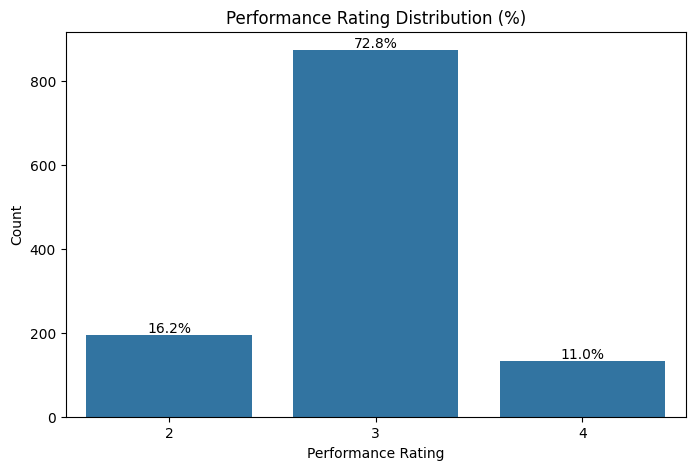

In [114]:
# performance rating distribution with parcentage
plt.figure(figsize=(8,5))

ax = sns.countplot(data=df, x='PerformanceRating')

total = len(df)

# add percentage labels
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.title('Performance Rating Distribution (%)')
plt.xlabel('Performance Rating')
plt.ylabel('Count')
plt.show()

#### Obervation
---
From the visual  we have a rating 2 indicating low performance, 3 indicating good performance and and 4 indicating Excellent performance. Rating 3 is high with a count of nearly 850, followed Rating 2 with nearly 195 employees  then rating 4 with  nearly 130 employees. This indicates that majority of employees are clustered in Rating 3 which is a  good rating, then our  major target the low peformers at Rating 2 and be able to understand and get who they are, why are they Underperforming and where they are concentrated

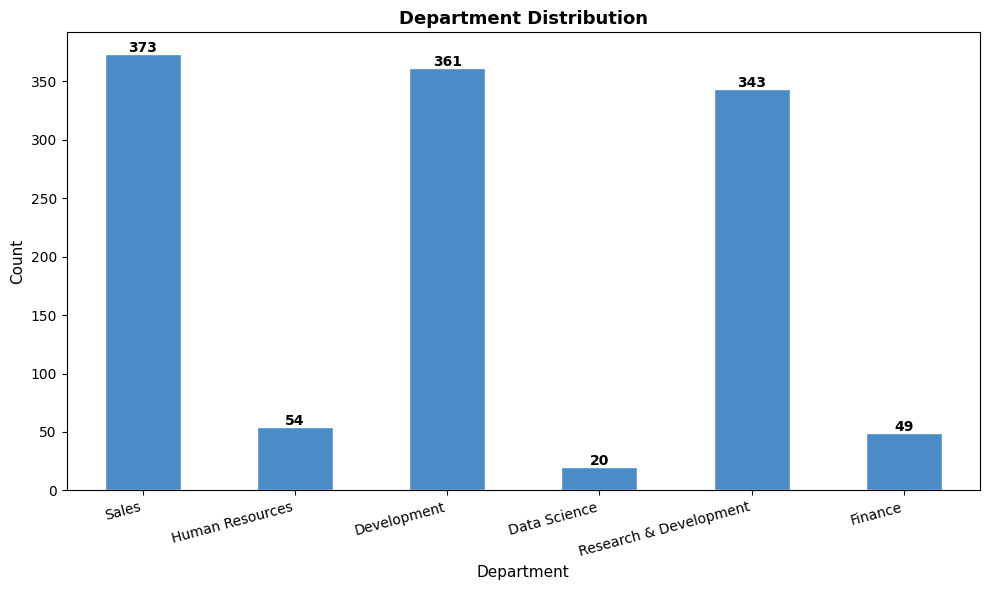

In [115]:
plt.figure(figsize=(10, 6))

sns.countplot(x='EmpDepartment', data=df,
              color='#378ADD', edgecolor='white', width=0.5)

plt.title('Department Distribution', fontweight='bold', fontsize=13)
plt.xlabel('Department', fontsize=11)
plt.ylabel('Count', fontsize=11)

for p in plt.gca().patches:
    count = int(p.get_height())
    plt.text(p.get_x() + p.get_width()/2, p.get_height() + 2,
             f'{count}',
             ha='center', fontsize=10, fontweight='bold')

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

#### Obervation
---
This is a countplot showing the raw number of employees in each department across INX Future Inc.
Sales, Development and Research & Development has the highest count of employees,Human Resourse, Data Science and Finance has a low count of employees. There is a huge imbalance within departments.

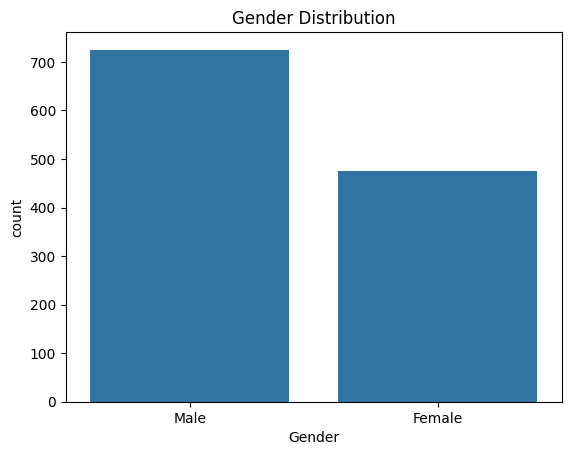

In [116]:
# Checking gender distribution
sns.countplot(x='Gender', data=df)

plt.title('Gender Distribution')
plt.show()

#### Obervation
---
This is a countplot showing the count of Male & Female employees in  INX Future Inc.There are more male employees in the company compared  to Female Employees

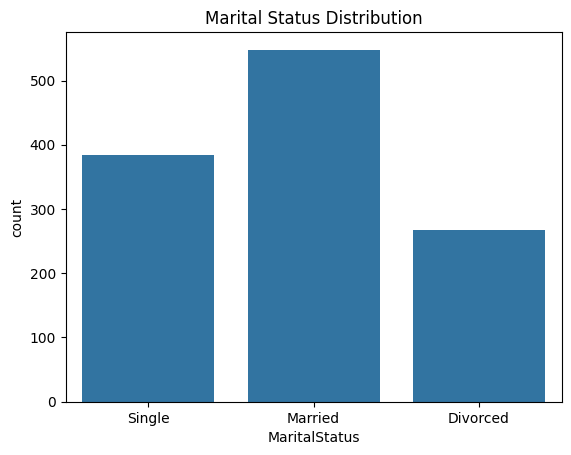

In [117]:
# marital status distribution
sns.countplot(x='MaritalStatus', data=df)
plt.title('Marital Status Distribution')
plt.show()

#### Obervation
---
This is a countplot on Marital status showing the no of married, Single & Divorced employees in the company.Married people have the highest number with a count of 548, followed by the single with 348 then divorced with a count of 268

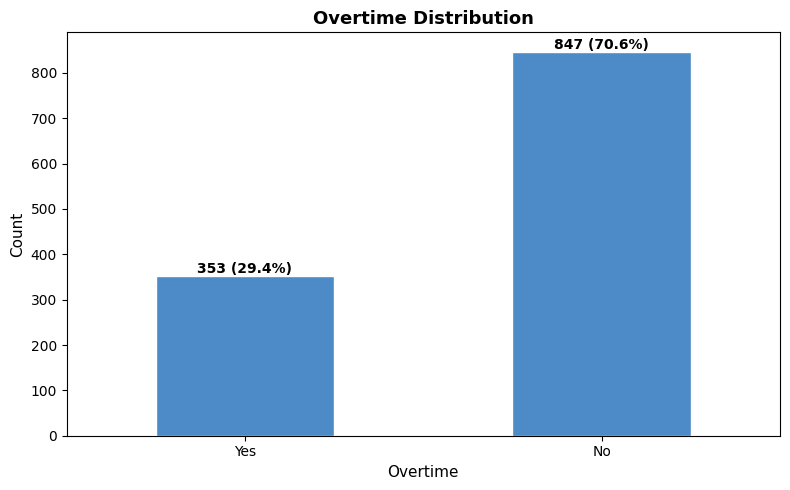

In [118]:
plt.figure(figsize=(8, 5))

sns.countplot(x='OverTime', data=df,
              order=['Yes', 'No'],
              color='#378ADD', edgecolor='white', width=0.5)

plt.title('Overtime Distribution', fontweight='bold', fontsize=13)
plt.xlabel('Overtime', fontsize=11)
plt.ylabel('Count', fontsize=11)

for p in plt.gca().patches:
    count = int(p.get_height())
    plt.text(p.get_x() + p.get_width()/2, p.get_height() + 5,
             f'{count} ({count/len(df)*100:.1f}%)',
             ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

#### Obervation
---
This a count plot showing overtime distribution.353 employees at INX Future Inc are working overtime,with 847 not working overtime

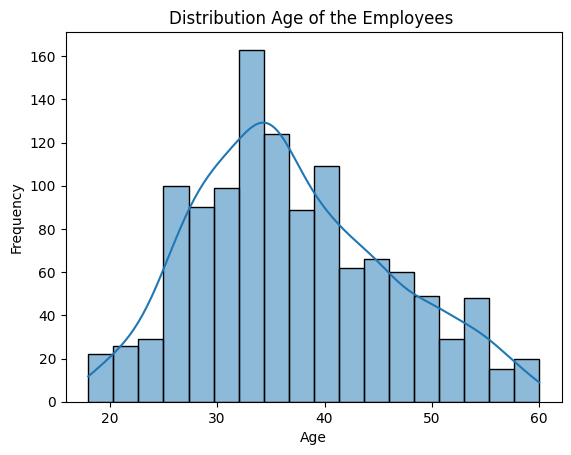

In [119]:
sns.histplot(df['Age'], kde=True)
plt.title('Distribution Age of the Employees ')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

#### Obervation
---
This is a histogram with a KDE curve showing the age distribution of all 1200 INX employees.
18-25 years has nearly 170 employees rising steeply
26-30 years nearly 400 employees
30-35 years peaks at 163 , highest bar (age 33-34)
Then there is agradual decline in the no from 40 years to 60 years
The distribution is right skewed,  meaning most employees are young to middle aged with fewer older employees

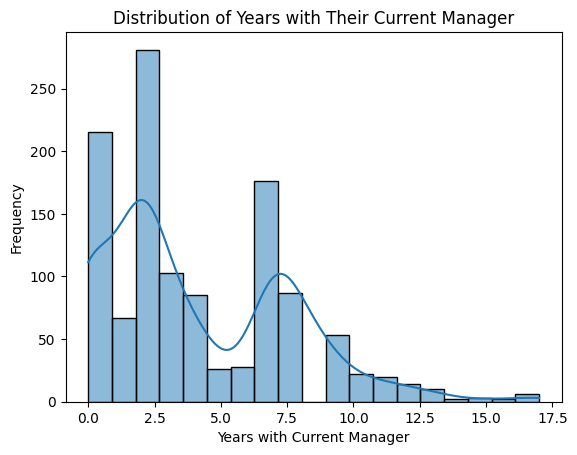

In [120]:
sns.histplot(df['YearsWithCurrManager'], kde=True)
plt.title('Distribution of Years with Their Current Manager')
plt.xlabel('Years with Current Manager')
plt.ylabel('Frequency')
plt.show()

#### Obervation
---
This is a histogram with a KDE curve showing how long employees have been working under their current manager. 

* 0-1 years has nearly 218 employees which is very high
* 2-3 years has nearly 280 employees , this is the highest peak
* 4-5 years nearly 190 employees
* 6-7 years has around 175 employees , this is the second peak
* 8-10 years nearly 130 employees. Post 10-17 years there is significant decrease in the no of employees 

The distribution is bimodal, there is two distinct peaks, one between 2 years and the other at 7 years, 

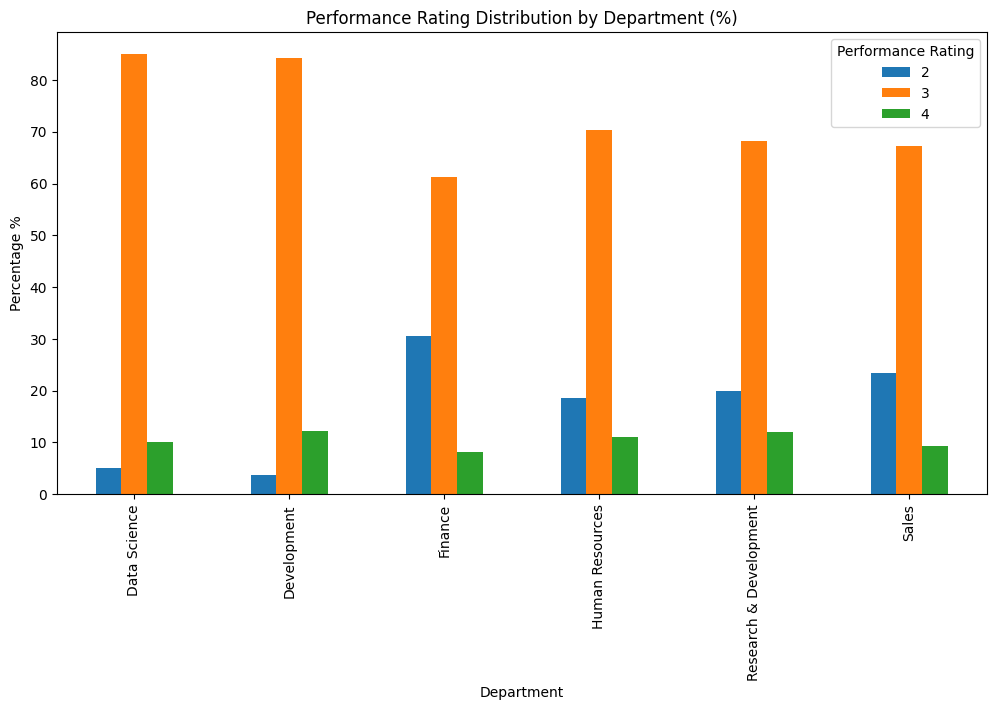

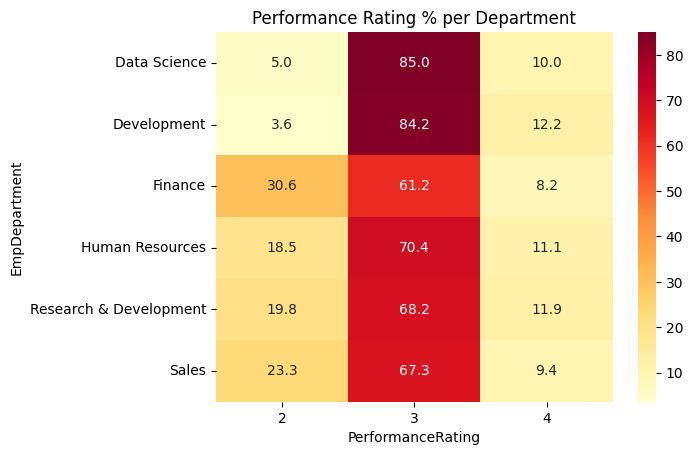

In [121]:
# Calculate proportion within each department
dept_perf = df.groupby('EmpDepartment')['PerformanceRating'].value_counts(normalize=True).mul(100).round(2)


dept_perf.unstack().plot(kind='bar', figsize=(12,6))
plt.title('Performance Rating Distribution by Department (%)')
plt.ylabel('Percentage %')
plt.xlabel('Department')
plt.legend(title='Performance Rating')
plt.show()


# Cross tab normalized by row (each department sums to 100%)
ct = pd.crosstab(df['EmpDepartment'], 
                 df['PerformanceRating'], 
                 normalize='index').mul(100).round(2)

sns.heatmap(ct, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Performance Rating % per Department')
plt.show()

#### Obervation
---
This is a normalized grouped barplot showing the percentage of each performance rating within each department.Data Science & Development has the healthiest performance distribution ,over 84% of their staff rated Good or Excellent,with low rate performers. Finance, Sales, Research & development and Human Resource has the highers number of low performers respectively. All departments have between 8% to 12.5% of Excellent performers led by Development and the lowest Finance. This is significanly important to Mr Brain as it uncovers each and every department performance and answers where performance problem is concentrated. Finance need an urgent intervention  with 30.6% low performers, followed by sales at 23.3% then research and development at 19.8%

In [122]:
# Department-wise performance summary
dept_summary = df.groupby('EmpDepartment').agg(
    Total_Employees=('EmpNumber', 'count'),
    Average_Rating=('PerformanceRating', 'mean')
)

# Add percentage distribution of ratings
dept_summary['Low_%'] = df[df['PerformanceRating'] == 2].groupby('EmpDepartment')['PerformanceRating'].count() / df.groupby('EmpDepartment')['PerformanceRating'].count() * 100
dept_summary['Good_%'] = df[df['PerformanceRating'] == 3].groupby('EmpDepartment')['PerformanceRating'].count() / df.groupby('EmpDepartment')['PerformanceRating'].count() * 100
dept_summary['Excellent_%'] = df[df['PerformanceRating'] == 4].groupby('EmpDepartment')['PerformanceRating'].count() / df.groupby('EmpDepartment')['PerformanceRating'].count() * 100

# Fill missing values and round
dept_summary = dept_summary.fillna(0).round(1)

# Sort by average rating
dept_summary = dept_summary.sort_values(by='Average_Rating', ascending=False)

print(dept_summary)

                        Total_Employees Average_Rating  Low_%  Good_%  \
EmpDepartment                                                           
Development                         361       3.085873    3.6    84.2   
Data Science                         20           3.05    5.0    85.0   
Human Resources                      54       2.925926   18.5    70.4   
Research & Development              343       2.921283   19.8    68.2   
Sales                               373        2.86059   23.3    67.3   
Finance                              49        2.77551   30.6    61.2   

                        Excellent_%  
EmpDepartment                        
Development                    12.2  
Data Science                   10.0  
Human Resources                11.1  
Research & Development         12.0  
Sales                           9.4  
Finance                         8.2  


#### Obervation
---
The results show employee performance distribution across different departments based on average ratings and rating categories (Low, Good, Excellent).

1. Development - has the highest average rating (3.1) and the strongest performance distribution, with 84.2% of employees rated as Good and only 3.6% as Low performers, indicating a highly productive team.
2. Data Science - shows strong performance with an average rating of 3.0, and 85% Good performers, making it one of the most consistent departments.
3. Human Resources and Research - show moderate performance levels with average ratings around 2.9. However, they also have a higher proportion of Low performers (18–19%), indicating some performance concerns.
4. The Sales - despite having the largest workforce (373 employees), shows a slightly lower average rating (2.9) and a higher Low performer percentage (23.3%), suggesting variability in employee performance.
5. The Finance Department has the lowest average rating (2.8) and the highest percentage of Low performers (30.6%), indicating a need for targeted improvement and performance management strategies.

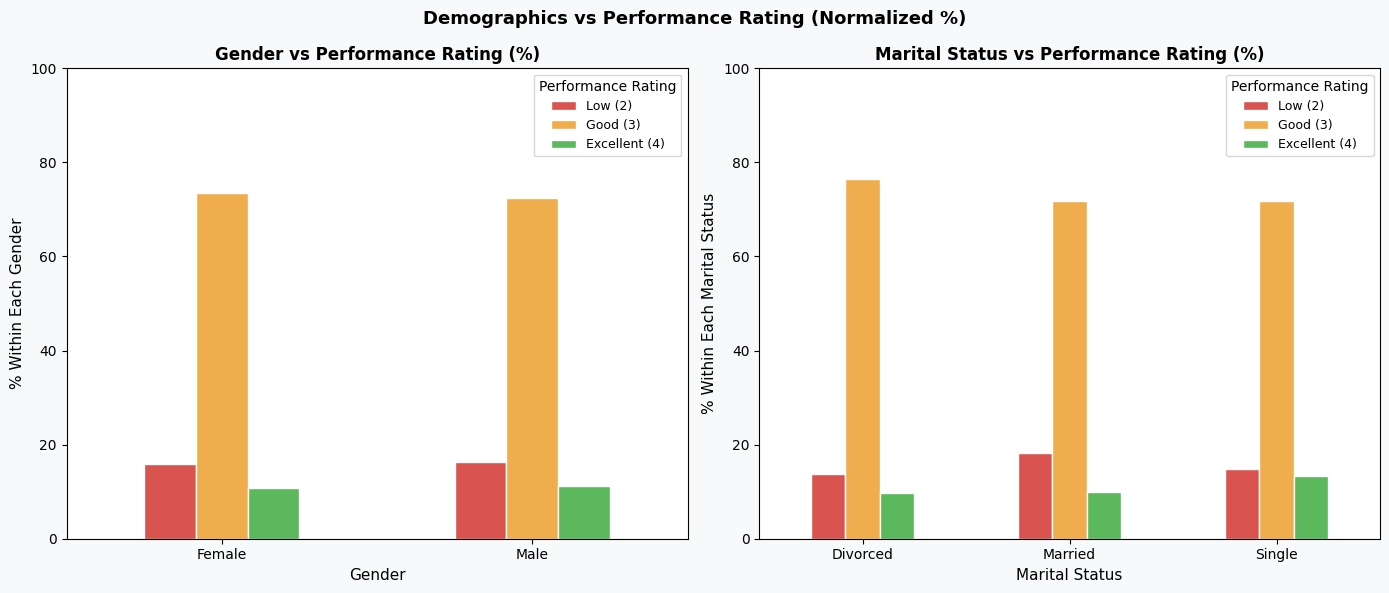

In [123]:
# Gender and Marital status vs perfomance rating
df['PerformanceRating'] = df['PerformanceRating'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#F8F9FA')

#  Chart 1: Gender vs Performance Rating ──
ct1 = pd.crosstab(df['Gender'], df['PerformanceRating'],
                  normalize='index').mul(100).round(1)

ct1.plot(kind='bar', ax=axes[0],
         color=['#D9534F', '#F0AD4E', '#5CB85C'],
         edgecolor='white', rot=0, width=0.5)

axes[0].set_title('Gender vs Performance Rating (%)',
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel('Gender', fontsize=11)
axes[0].set_ylabel('% Within Each Gender', fontsize=11)
axes[0].set_ylim(0, 100)
axes[0].legend(title='Performance Rating',
               labels=['Low (2)', 'Good (3)', 'Excellent (4)'],
               fontsize=9)
axes[0].tick_params(axis='x', rotation=0)

#  Chart 2: Marital Status vs Performance Rating ──
ct2 = pd.crosstab(df['MaritalStatus'], df['PerformanceRating'],
                  normalize='index').mul(100).round(1)

ct2.plot(kind='bar', ax=axes[1],
         color=['#D9534F', '#F0AD4E', '#5CB85C'],
         edgecolor='white', rot=0, width=0.5)

axes[1].set_title('Marital Status vs Performance Rating (%)',
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel('Marital Status', fontsize=11)
axes[1].set_ylabel('% Within Each Marital Status', fontsize=11)
axes[1].set_ylim(0, 100)
axes[1].legend(title='Performance Rating',
               labels=['Low (2)', 'Good (3)', 'Excellent (4)'],
               fontsize=9)
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Demographics vs Performance Rating (Normalized %)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Obervation
---
This is two normalized crosstab barplots side by side showing how performance rating is distributed within each gender group (left) and within each marital status group (right). Both are normalized so each group sums to 1OO%

**Gender**
Most indivuals  are clustered around 3 rating, there is no much difference between 2% and 3% rating on both genders meaning they averagely perform equally.This tells us gender has almost no impact on performance at INX.

**Marital Status**
Married individuals underperform slightly more as compared to divorced and single, followed by divorced and single but with a slight difference.

Married employees underperform slightly more , possibly due to family responsibilities and work life balance pressures


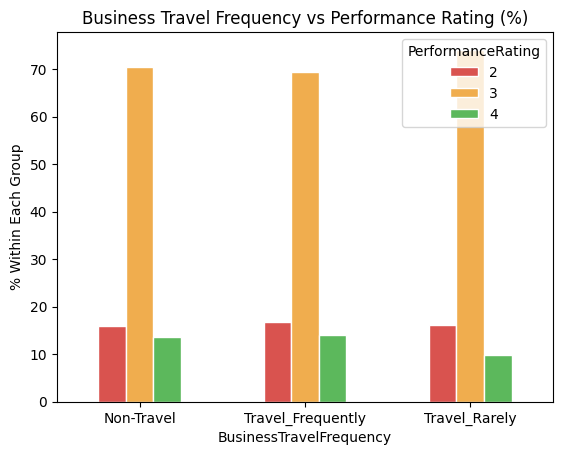

In [124]:
ct = pd.crosstab(df['BusinessTravelFrequency'], df['PerformanceRating'],
                 normalize='index').mul(100).round(1)
ct.plot(kind='bar',   color=['#D9534F', '#F0AD4E', '#5CB85C'],
        edgecolor='white', rot=0)
plt.title('Business Travel Frequency vs Performance Rating (%)')
plt.ylabel('% Within Each Group')
plt.show()

#### Obervation
---
This is a normalized crosstab barplot showing how performance rating is distributed within each business travel frequency group. On 3% rating , individuals who travely rarely tend to perform higher compared  to Non- Traveelers and those  who travel frequently, On 2% rating frequent travellers tend to underform slightly more compared  to non travellers and rare travellers.They dont show so much diffference between each other Indicating that Travel frequency is not a major driver of the performance problem.


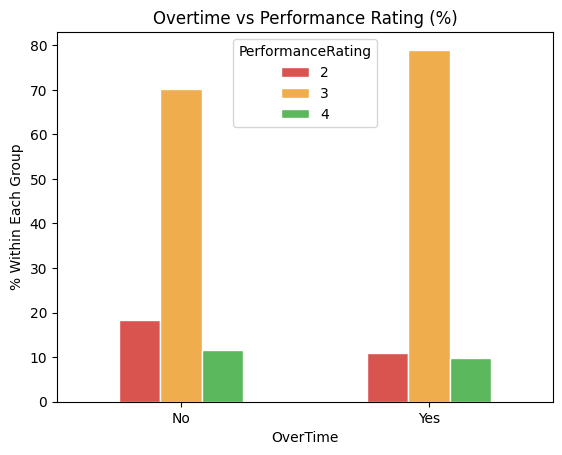

In [125]:
ct = pd.crosstab(df['OverTime'], df['PerformanceRating'],
                 normalize='index').mul(100).round(1)
ct.plot(kind='bar',   color=['#D9534F', '#F0AD4E', '#5CB85C'],
        edgecolor='white', rot=0)
plt.title('Overtime vs Performance Rating (%)')
plt.ylabel('% Within Each Group')
plt.show()


#### Obervation
---
This is a normalized crosstab barplot showing how performance rating is distributed within each overtime group. Low(2)   Good(3)   Excellent(4)
No Overtime  group has nearly 18% of low performers, 70% of Good performers and nearly 12 % of Excellent performers 
Yes Overtime  employees has around 11% of excellent performers, 79% of Good performers and 10% 
Non overtime employees have more low performers than overtime workers 
On excellent performance, they are nearly identical across both groups 
overtime has no really much impact on producing excellent performers whatsoever.


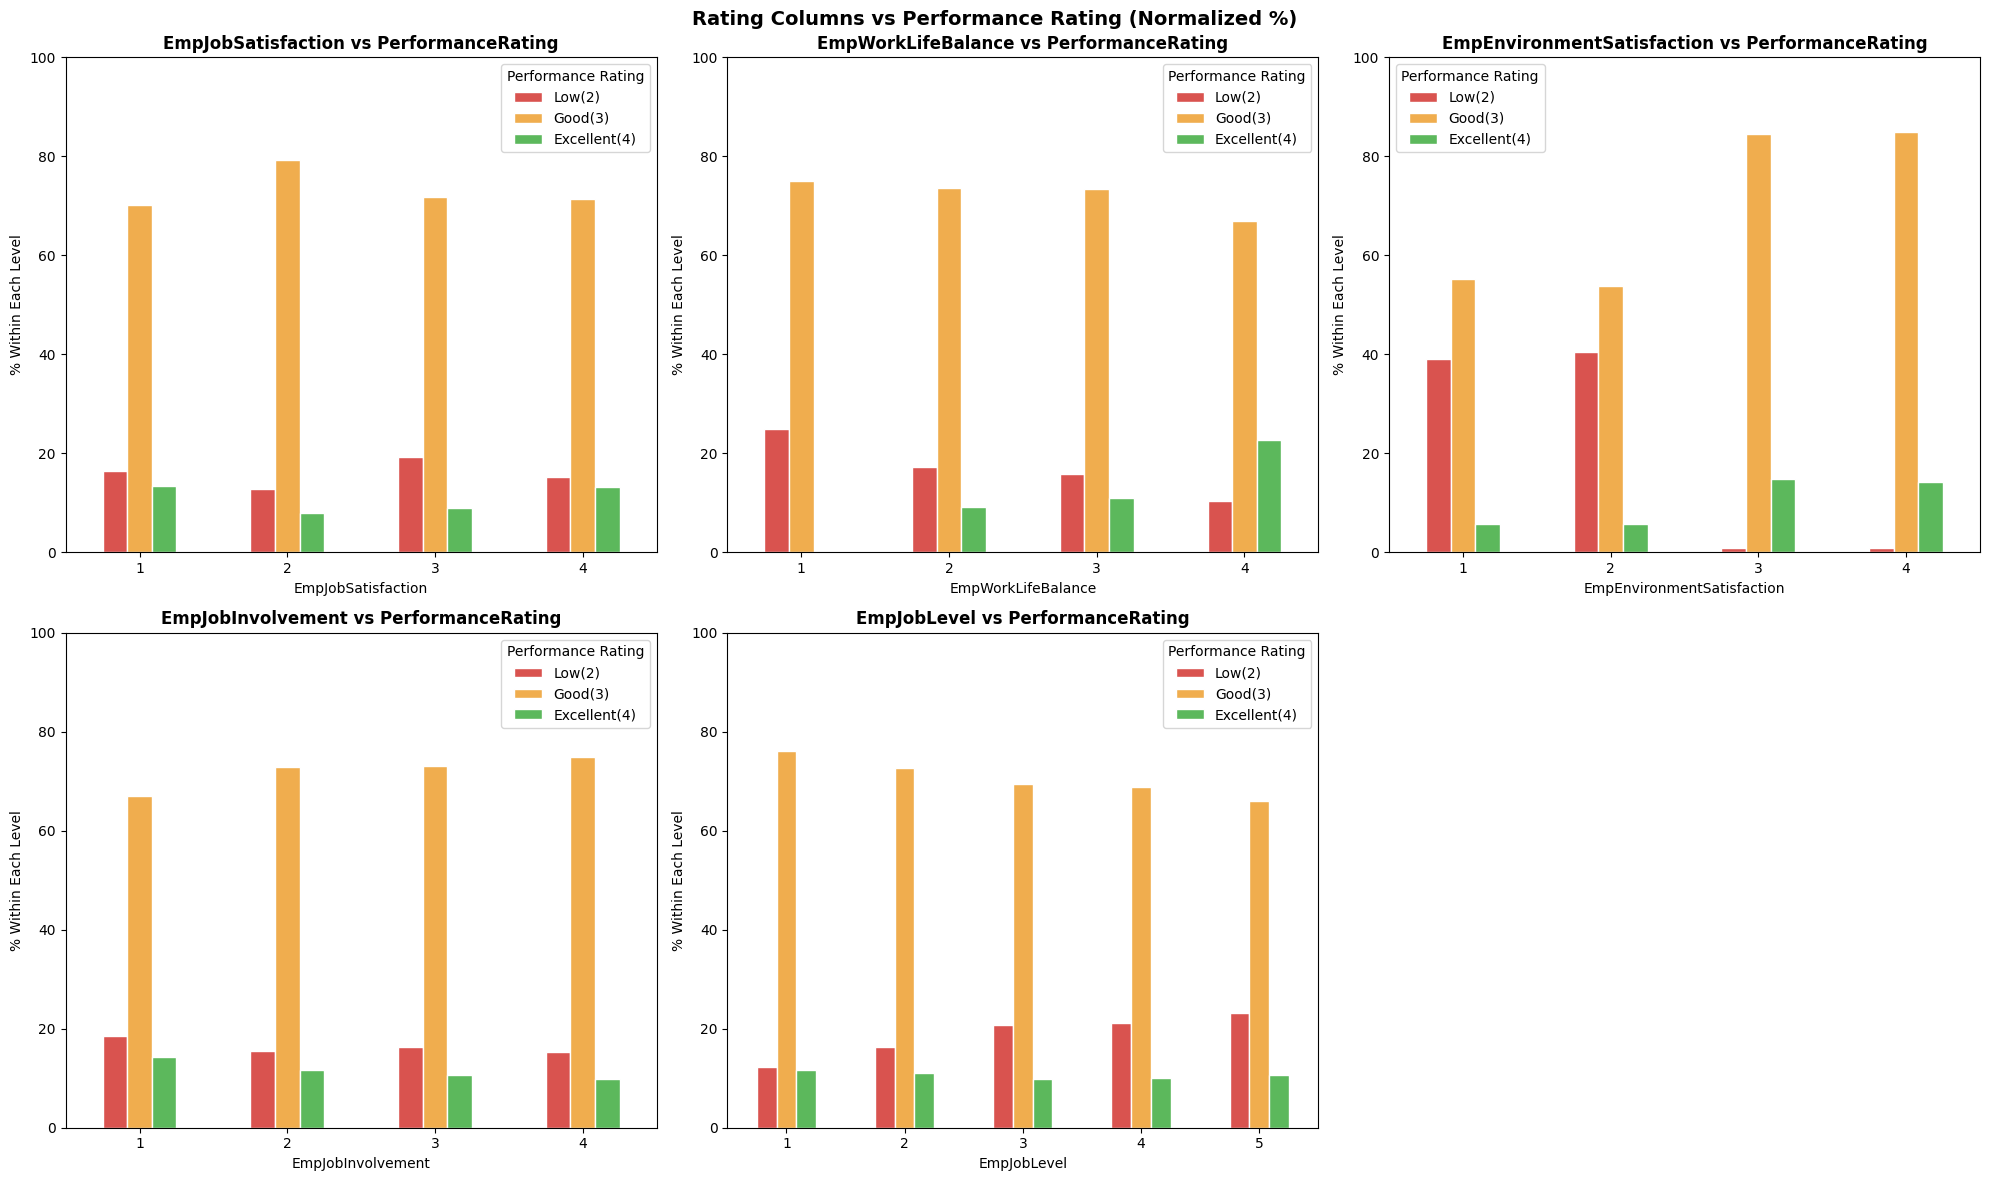

In [126]:
# Cross tab normalized by column (each performance rating sums to 100%)
ct_col = pd.crosstab(df['EmpDepartment'], 
                     df['PerformanceRating'], 
                     normalize='columns').mul(100).round(2)
# Columns to plot
cols = ['EmpJobSatisfaction','EmpWorkLifeBalance','EmpEnvironmentSatisfaction',
        'EmpJobInvolvement','EmpJobLevel'
        ,]


fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    ct = pd.crosstab(df[col], df['PerformanceRating'], 
                     normalize='index').mul(100).round(1)
    ct.plot(kind='bar', ax=axes[i], 
            color=['#D9534F', '#F0AD4E', '#5CB85C'], 
            edgecolor='white', rot=0)
    axes[i].set_title(f'{col} vs PerformanceRating', fontweight='bold')
    axes[i].set_ylabel('% Within Each Level')
    axes[i].set_ylim(0, 100)
    axes[i].legend(title='Performance Rating', 
                   labels=['Low(2)','Good(3)','Excellent(4)'])

axes[5].set_visible(False)
plt.suptitle('Rating Columns vs Performance Rating (Normalized %)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Obervation
---
This is a combined figure of 5 normalized crosstab barplots showing how performance rating is distributed within each level of five satisfaction and involvement columns. 

**Emloyee job satisfaction**

There is no clear consistent pattern across levels — low performers exist at every satisfaction level fairly equally ranging from 12.7% to 19.2%. The most interesting finding is level 2 has the fewest low performers at 12.7% but also the fewest excellent performers at 8.0% ,suggesting moderate satisfaction produces stable but not exceptional performance.
Level 1 and 4 have the most excellent performers at 13.4% and 13.2% indicating either very low or very high satisfaction pushes employees towards extreme performance outcomes.
 
**Employee work life balance**

It has 4 levels. Level one has only low and good performers,at nearly 25% and 75% respectively. Level 2 has all the ratings but excellent performers are very few at around  8% with low performers at around 17%. Level 3 has an increased percentage of excellent performers at nearly 10% and low performers percentage reducing with a percentage of nearly 15% and good performers at around 75%. Level 4 has a significant  increase in excellent performers at neraly 23 %, low performers nearly at 10% and good performers at around 63%
As work life balance improves ,low performers decrease and excellent performers increase
Work life balance has a direct and consistent relationship with performance rating making it one of the most actionable findings for Mr. Brain.

**Employee Environment Satisfaction**

It has 4 levels.Level 1 and 2 have the highest no of low performers, 38-40% low performers and 5% of excellent performers.
Level 3 and 4  has less than 1% low performers  nearly  zero.
There is a huge difference in this as employees who rate their environment as satisfactory or above 3 almost never become low performers. This suggests environment satisfaction is a threshold variable , once it crosses level 3 performance dramatically improves.Mr Brain should keenly look at emloyee job environment as it highly afffects performance greatly 

**Employee job involvement**

There is Very little variation across levels. Low performers range from 14.9% to 18.8% across all involvement levels. Job involvement alone does not strongly separate performance groups. However level 1 (lowest involvement) has slightly more low performers and level 4 (highest involvement) has slightly fewer 

**Employee job level**

As job level increases ,low performers INCREASE

 Level 1 only  has 11.6% low performers
 
Level 5 has 23.2% low performers


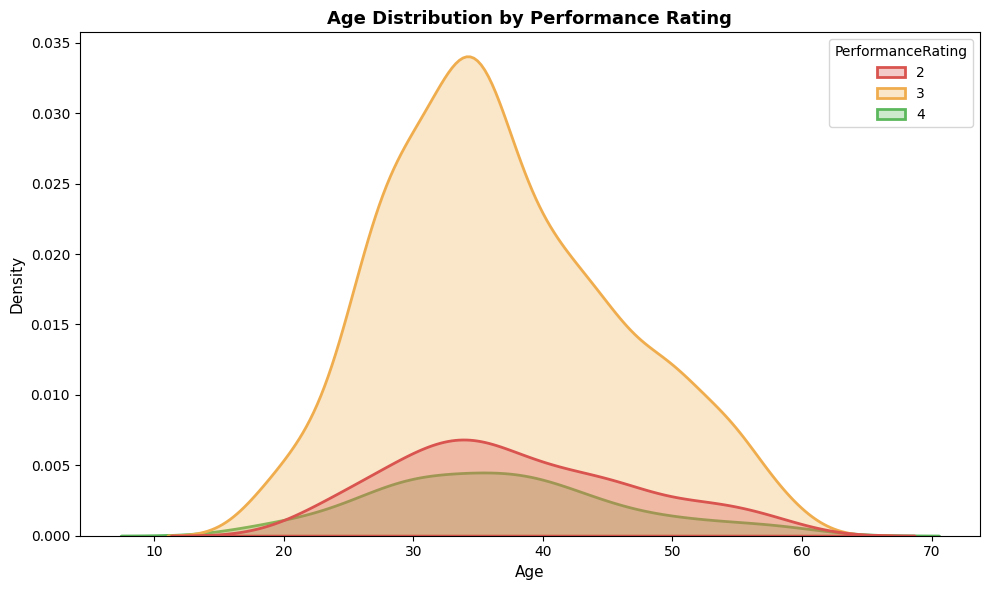

In [127]:
df['Age'] = df['Age'].astype(int)
df['PerformanceRating'] = df['PerformanceRating'].astype(str)

palette = {'2':'#D9534F', '3':'#F0AD4E', '4':'#5CB85C'}

plt.figure(figsize=(10, 6))

sns.kdeplot(data=df, x='Age',
            hue='PerformanceRating',
            hue_order=['2', '3', '4'],
            palette=palette,
            fill=True, alpha=0.3, linewidth=2)

plt.title('Age Distribution by Performance Rating',
          fontweight='bold', fontsize=13)
plt.xlabel('Age', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.tight_layout()
plt.show()

#### Obervation
---
This is a KDE (Kernel Density Estimation) plot showing the age distribution of employees for each performance rating group.The filled curves show where each performance group is most densely concentrated by age. All three curves peak around age 30-38.
Rating 3 is the tallest curve  it peaks sharply at age 34
Rating 2  is the  flatter curve ,spreads from age 20 to 60,mostly concentrated between age 30-38
Rating 4 is the  flattest curve it is almost invisible under the others and mostly concentrated between age 30-38
All three performance groups follow almost the same age distribution — younger employees between 25 and 40 make up the majority of every performance group.This indicates that Age is not a driver of performance at INX. The company cannot attribute poor performance to having too many young or too many old employees. Performance issues exist equally across all age groups.

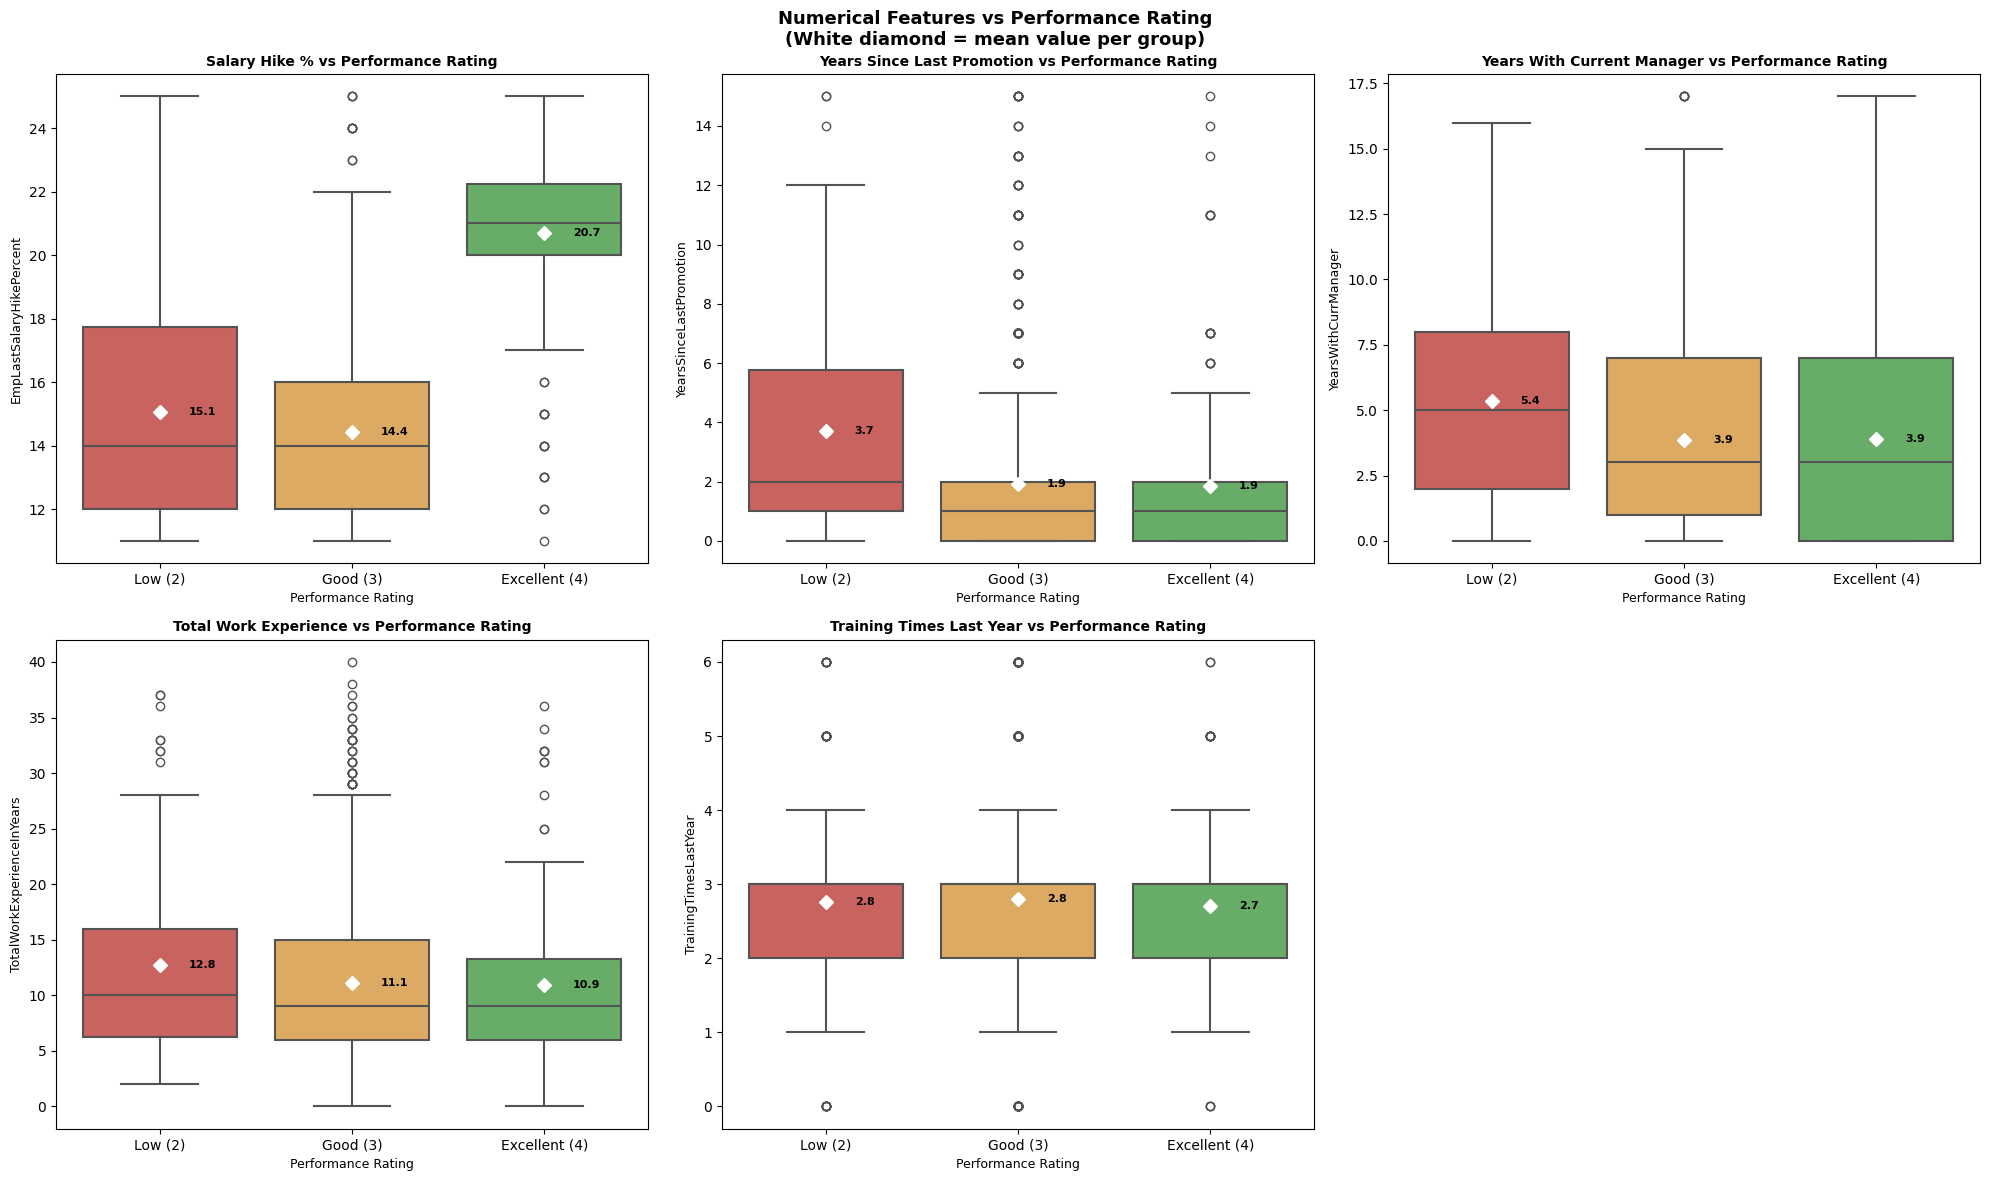

In [128]:
cols = ['EmpLastSalaryHikePercent', 'YearsSinceLastPromotion',
        'YearsWithCurrManager', 'TotalWorkExperienceInYears',
        'TrainingTimesLastYear']

titles = ['Salary Hike % vs Performance Rating',
          'Years Since Last Promotion vs Performance Rating',
          'Years With Current Manager vs Performance Rating',
          'Total Work Experience vs Performance Rating',
          'Training Times Last Year vs Performance Rating']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, (col, title) in enumerate(zip(cols, titles)):


    sns.boxplot(x='PerformanceRating', y=col,
                hue='PerformanceRating',        
                hue_order=['2', '3', '4'],      
                order=['2', '3', '4'],
                palette=palette,
                legend=False,                   
                data=df, ax=axes[i], linewidth=1.5)

    # Add mean markers
    means = df.groupby('PerformanceRating')[col].mean().reindex(['2', '3', '4'])
    for j, mean_val in enumerate(means):
        axes[i].plot(j, mean_val, 'D', color='white', markersize=7, zorder=5)
        axes[i].text(j + 0.15, mean_val, f'{mean_val:.1f}',
                     fontsize=8, fontweight='bold', va='center')

    axes[i].set_title(title, fontweight='bold', fontsize=10)

    # Fix 2 — use set_xticks before set_xticklabels
    axes[i].set_xticks([0, 1, 2])
    axes[i].set_xticklabels(['Low (2)', 'Good (3)', 'Excellent (4)'])

    axes[i].set_xlabel('Performance Rating', fontsize=9)
    axes[i].set_ylabel(col, fontsize=9)

axes[5].set_visible(False)

plt.suptitle('Numerical Features vs Performance Rating\n'
             '(White diamond = mean value per group)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Obervation
---
The bivariate analysis revealed that **salary hike percentage** and **years since last promotion** have the strongest relationship with employee performance. Employees with excellent performance ratings generally received higher salary increments and more recent promotions compared to low-performing employees. In contrast, **total work experience**, **years with the current manager**, and **training frequency** showed weaker associations with performance ratings. Overall, the findings suggest that career growth opportunities, recognition through salary increases, and timely promotions play a more significant role in influencing employee performance than experience or training alone.


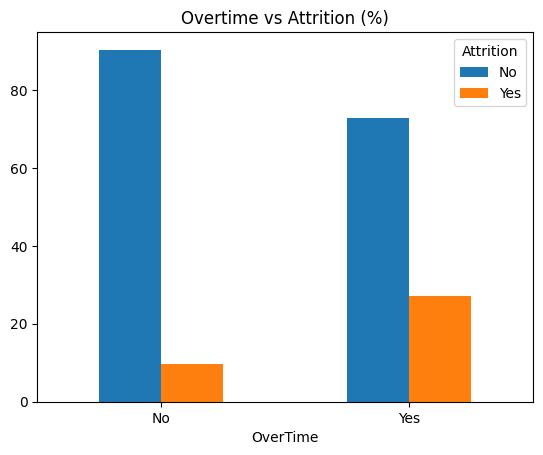

In [129]:
# OverTime vs Attrition 
ct2 = pd.crosstab(df['OverTime'], df['Attrition'],
                  normalize='index').mul(100).round(1)
ct2.plot(kind='bar', rot=0)
plt.title('Overtime vs Attrition (%)')
plt.show()

#### Obervation
---
This is a normalized crosstab barplot showing the percentage of employees who stayed or left within each overtime group
No Overtime employees stayed with a 90%  & left at 10%
Yes Overtime employees stayed at 73%   and left at 30% 
Overtime workers are nearly 3 times more likely to leave than non overtime workers. 
This directly explains the 8% drop in client satisfaction , when experienced capable employees leave, service quality inevitably declines.
Reducing overtime is the most impactful single action Mr. Brain can take to immediately reduce attrition.


<Axes: xlabel='EmpDepartment'>

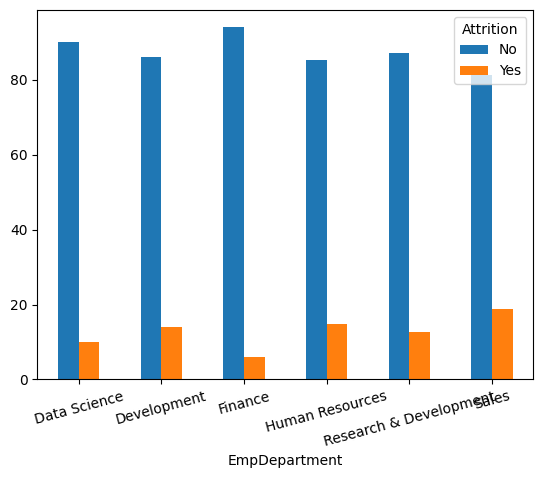

In [130]:
# Attrition vs Department (normalized)
ct = pd.crosstab(df['EmpDepartment'], df['Attrition'],
                 normalize='index').mul(100).round(1)
ct.plot(kind='bar', rot=15)

#### Obervation
---
This is a normalized crosstab barplot showing the percentage of employees who stayed or left within each department. 
Data Science  employees stayed at 90.0% and left at 10.0%
Development employees stayed at 86% and left at 14%
Finance  employees stayed at 94.0% and left at 6.0% 
Human Resources employees stayed at 85%  and left at 15.0%
Research & Development employees stayed at 86.9% and left at 13.1%
Sales employees stayed 81% and left at 19% 
Sales has the highest attrition and Finance with the lowest attrition


<Axes: xlabel='BusinessTravelFrequency'>

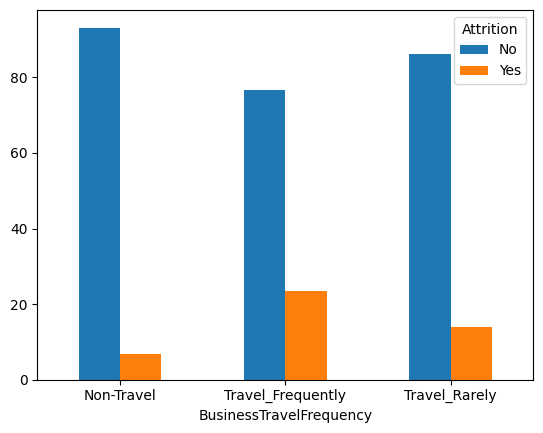

In [131]:
# Attrition vs BusinessTravel
ct3 = pd.crosstab(df['BusinessTravelFrequency'], df['Attrition'],
                  normalize='index').mul(100).round(1)
ct3.plot(kind='bar', rot=0)

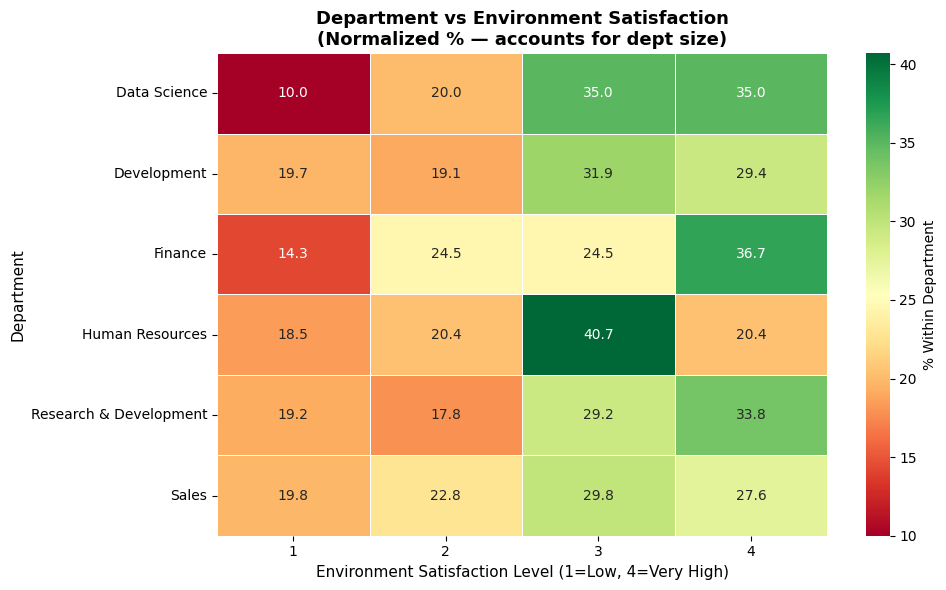

In [132]:
df['EmpEnvironmentSatisfaction'] = df['EmpEnvironmentSatisfaction'].astype(str)

# Normalized pivot — % within each department
pivot = df.groupby(['EmpDepartment', 'EmpEnvironmentSatisfaction']).size().unstack()
pivot = pivot.div(pivot.sum(axis=1), axis=0).mul(100).round(1)

plt.figure(figsize=(10, 6))

sns.heatmap(pivot, annot=True, fmt='.1f',
            cmap='RdYlGn', linewidths=0.5,
            linecolor='white',
            cbar_kws={'label': '% Within Department'})

plt.title('Department vs Environment Satisfaction\n(Normalized % — accounts for dept size)',
          fontweight='bold', fontsize=13)
plt.xlabel('Environment Satisfaction Level (1=Low, 4=Very High)', fontsize=11)
plt.ylabel('Department', fontsize=11)
plt.tight_layout()
plt.show()

In [133]:
df['PerformanceRating'].value_counts()

PerformanceRating
3    874
2    194
4    132
Name: count, dtype: int64

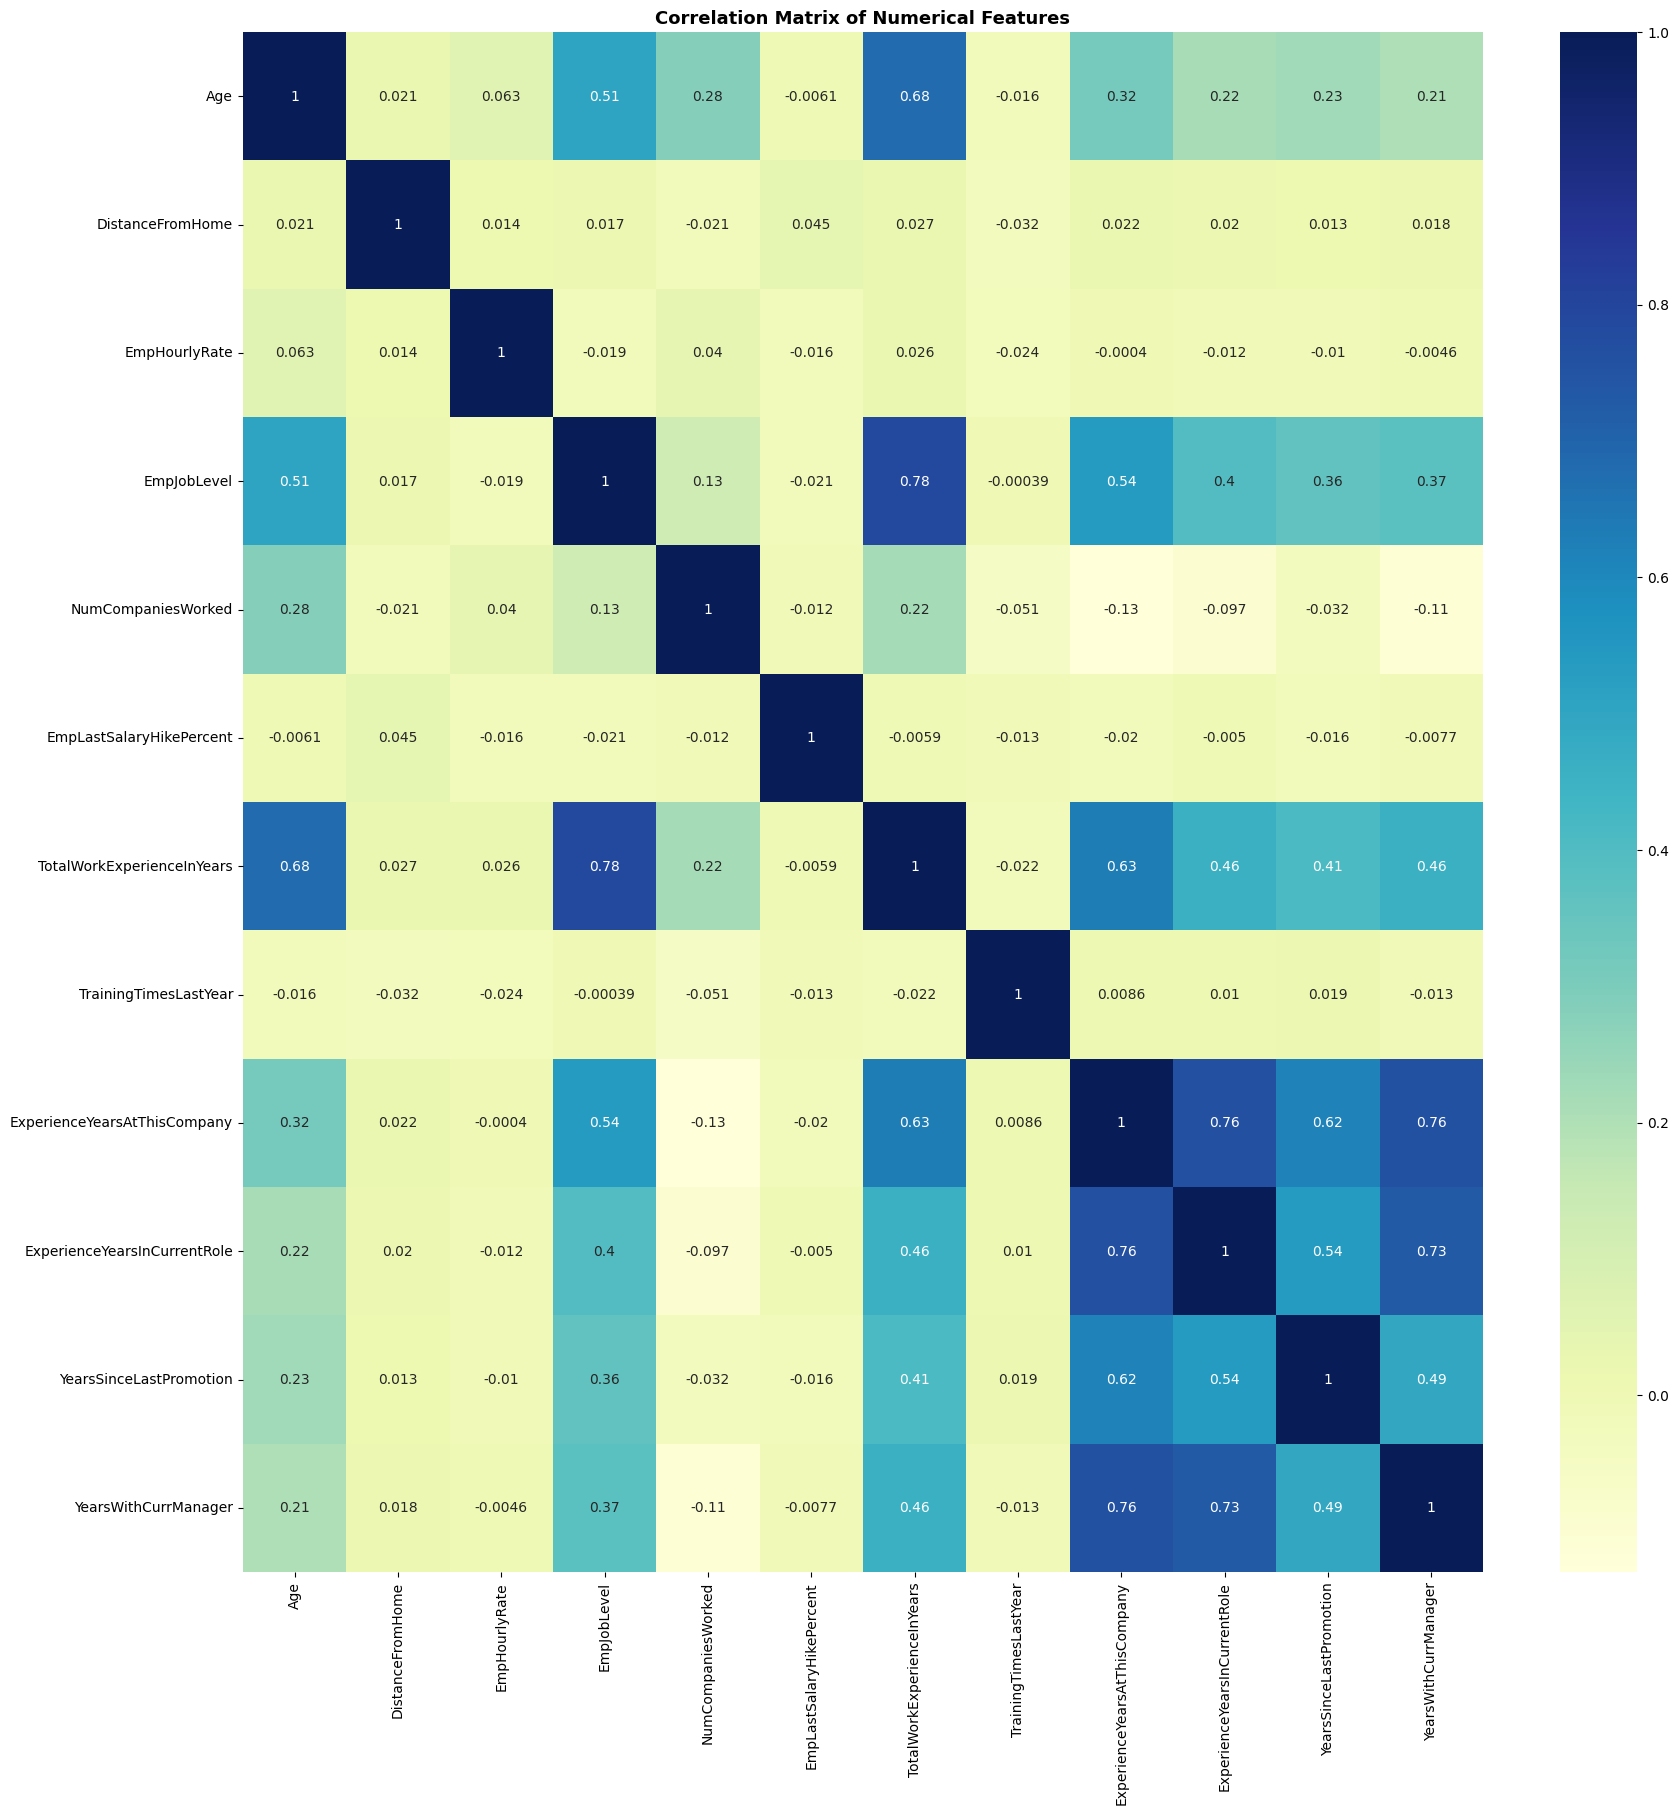

In [134]:
# Correlation matrix for numerical features
# define numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(20,20))
sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap='YlGnBu'
)
plt.title('Correlation Matrix of Numerical Features',
          fontweight='bold',
          fontsize=13)
plt.show()

#### Obervation
---
The correlation heatmap shows relationships between employee attributes and the Performance Rating. Most variables have weak correlations, indicating that employee performance is influenced by a combination of multiple factors rather than a single strong factor.

The strongest positive relationship is seen with EmpEnvironmentSatisfaction (0.40), meaning employees who are more satisfied with their work environment tend to perform better. Another important positive factor is EmpLastSalaryHikePercent (0.33), showing that employees who receive higher salary increases generally have better performance ratings.

Several features show weak to moderate negative correlations, such as YearsSinceLastPromotion (-0.17), ExperienceYearsInCurrentRole (-0.15), and YearsWithCurrManager (-0.12), suggesting that longer time without promotion or role change may slightly reduce performance. Similarly, ExperienceYearsAtThisCompany (-0.11) and TotalWorkExperience (-0.068) show weak negative relationships.

Overall, the heatmap indicates that employee performance is most influenced by satisfaction, compensation growth, and career progression factors.

**Based on the correlation strength (absolute values), the most important features are**

* EmpEnvironmentSatisfaction (0.40)
* EmpLastSalaryHikePercent (0.33)
* YearsSinceLastPromotion (0.17)
* ExperienceYearsInCurrentRole (0.15)
* YearsWithCurrManager (0.12)
* EmpWorkLifeBalance (0.12)
* ExperienceYearsAtThisCompany (0.11)
* EmpJobLevel (0.077)
* TotalWorkExperienceInYears (0.068)
* DistanceFromHome (0.046)

## 5. PreProcessing
Data preprocessing involves cleaning and transforming employee record into suitable format for machine learning. Now will focus on encoding categorical variables and removing inconsistencies. 
This process ensures the data is well-structured and ready for accurate model training and analysis.

In [135]:
# one-hot encoding for categorical variables
encoder = LabelEncoder()
df.Gender  = encoder.fit_transform(df.Gender)
df.EducationBackground  = encoder.fit_transform(df.EducationBackground )
df.MaritalStatus = encoder.fit_transform(df.MaritalStatus)
df.EmpDepartment = encoder.fit_transform(df.EmpDepartment)
df.EmpJobRole = encoder.fit_transform(df.EmpJobRole)
df.BusinessTravelFrequency = encoder.fit_transform(df.BusinessTravelFrequency)
df.OverTime  = encoder.fit_transform(df.OverTime )
df.Attrition  = encoder.fit_transform(df.Attrition )
df.EmpWorkLifeBalance  = encoder.fit_transform(df.EmpWorkLifeBalance )
df.EmpEnvironmentSatisfaction  = encoder.fit_transform(df.EmpEnvironmentSatisfaction )

# Convert PerformanceRating to numeric
df['PerformanceRating'] = pd.to_numeric(df['PerformanceRating'], errors='coerce').astype(int)

# Remap PerformanceRating from [2, 3, 4] to [0, 1, 2] for zero-indexed classes
df['PerformanceRating'] = df['PerformanceRating'].map({2: 0, 3: 1, 4: 2})

#### Obervation
---
We applied Lebel encoding to convert all categorical variables into numerical format for machine learning.


In [136]:
# print the first few rows of the encoded dataset to verify the changes
df.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,1,2,2,5,13,2,10,3,...,4,10,2,1,10,7,0,8,0,1
1,E1001006,47,1,2,2,5,13,2,14,4,...,4,20,2,2,7,7,1,7,0,1
2,E1001007,40,1,1,1,5,13,1,5,4,...,3,20,2,2,18,13,1,12,0,2
3,E1001009,41,1,0,0,3,8,2,10,4,...,2,23,2,1,21,6,12,6,0,1
4,E1001010,60,1,2,2,5,13,2,16,4,...,4,10,1,2,2,2,2,2,0,1


## 6. Splitting data

In [137]:
# Define X (features) and y (target)

X = df[[
    "EmpEnvironmentSatisfaction",
    "EmpLastSalaryHikePercent",
    "YearsSinceLastPromotion",
    "ExperienceYearsInCurrentRole",
    "YearsWithCurrManager",
    "EmpWorkLifeBalance",
    "ExperienceYearsAtThisCompany",
    "EmpJobLevel",
    "TotalWorkExperienceInYears",
    "DistanceFromHome"
]]

y = df["PerformanceRating"]

# Check shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

# Check target distribution
print("\nPerformanceRating distribution:")
print(y.value_counts().sort_index())

# Check feature columns
print("\nFeature columns:")
print(X.columns.tolist())

X shape: (1200, 10)
y shape: (1200,)

PerformanceRating distribution:
PerformanceRating
0    194
1    874
2    132
Name: count, dtype: int64

Feature columns:
['EmpEnvironmentSatisfaction', 'EmpLastSalaryHikePercent', 'YearsSinceLastPromotion', 'ExperienceYearsInCurrentRole', 'YearsWithCurrManager', 'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany', 'EmpJobLevel', 'TotalWorkExperienceInYears', 'DistanceFromHome']


# 

#### Insight
---
Defined our X and y variables for modeling. X contains all the features except 'PerformanceRating', which is our target variable y. We also printed the shapes of X and y, the distribution of the target variable, and the list of feature columns in X to confirm everything is set up correctly for modeling.

## 7. Train and Test

In [138]:
#splitting the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y,
        test_size=0.2, # for 80-20 split
        random_state=42, # for reproducibility
        stratify=y)# Handling class imbalance by stratifying on target variable



# checking the shape of the train and test sets
print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)

X_train shape: (960, 10)
X_test shape:  (240, 10)
y_train shape: (960,)
y_test shape:  (240,)


#### Insight
---
We split the data into training and testing sets, with 80% of the data used for training and 20% for testing. We also set a random state  of 42 for reproducibility and stratified the split based on the target variable to maintain class distribution in both sets. We then checked the shapes of the resulting sets to confirm the split was successful.

In [139]:
# SMOTE analysis
smote = SMOTE(random_state = 42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)


## 8. Building Model and Evaluation


#### Decision Tree Model

In [140]:
# training a Decision Tree Classifier
dt = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

dt.fit(X_train_sm, y_train_sm)
y_pred_dt = dt.predict(X_test)

dt_acc = accuracy_score(y_test, y_pred_dt)

print(f"Accuracy: {dt_acc * 100:.2f}%")

print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=['Good(2)', 'Excellent(3)', 'Outstanding(4)']
    )
)

Accuracy: 83.75%
                precision    recall  f1-score   support

       Good(2)       0.72      0.74      0.73        39
  Excellent(3)       0.93      0.85      0.89       175
Outstanding(4)       0.59      0.88      0.71        26

      accuracy                           0.84       240
     macro avg       0.75      0.83      0.78       240
  weighted avg       0.86      0.84      0.84       240



#### Obervation
---
The Decision Tree Classifier achieved an overall accuracy of 83.75%, indicating that the model correctly predicted employee performance ratings for approximately 84% of employees in the test dataset. This result demonstrates that the model has strong predictive capability and can effectively classify employee performance levels.

**Good Performance (Rating = 2)**

The model achieved a precision of 72%, recall of 74%, and F1-score of 73% for employees classified as low performers. These results indicate moderate performance in identifying good performing employees, with some instances being incorrectly classified into other performance categories.

**Excellent Performance (Rating = 3)**

The model performed exceptionally well in predicting employees with excellent performance ratings, achieving a precision of 93%, recall of 85%, and F1-score of 89%. This indicates that the majority of employees in this category were correctly identified by the model. The strong performance is likely due to this class having the largest number of observations in the dataset.

**Outstanding Performance (Rating = 4)**

For employees with very excellent performance ratings, the model achieved a precision of 59%, recall of 88%, and F1-score of 71%. These results suggest that the model is highly effective at recognizing high-performing employees, although a small proportion were misclassified into neighboring performance categories

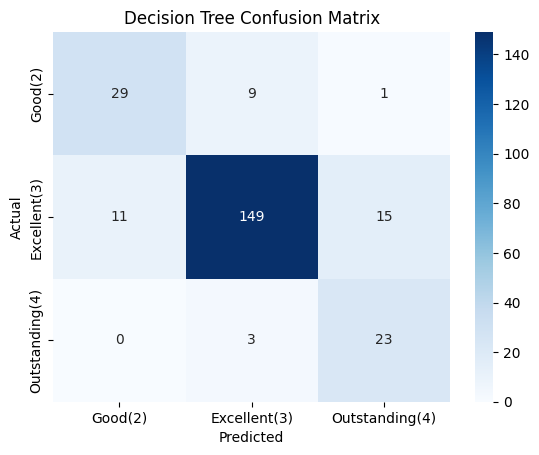

In [141]:
# visualize confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Good(2)', 'Excellent(3)', 'Outstanding(4)'],
            yticklabels=['Good(2)', 'Excellent(3)', 'Outstanding(4)'])
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted') 
plt.ylabel('Actual')
plt.show()

#### Random Forest

In [142]:
# training a Random Forest Classifier
rf = RandomForestClassifier(class_weight='balanced',
                             random_state=42,
                             n_estimators=100)
rf.fit(X_train_sm, y_train_sm)
y_pred_rf = rf.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {rf_acc*100:.2f}%")
print(classification_report(y_test, y_pred_rf,
  target_names=['Good(2)', 'Excellent(3)', 'Outstanding(4)']))


Random Forest Accuracy: 90.00%
                precision    recall  f1-score   support

       Good(2)       0.71      0.92      0.80        39
  Excellent(3)       0.95      0.91      0.93       175
Outstanding(4)       0.95      0.81      0.88        26

      accuracy                           0.90       240
     macro avg       0.87      0.88      0.87       240
  weighted avg       0.91      0.90      0.90       240



#### Obervation
---
The Random Forest Classifier achieved an overall accuracy of 90%, indicating that the model correctly predicted employee performance ratings for approximately 90% of employees in the test dataset. This high accuracy demonstrates that the model has excellent predictive capability and is highly effective in classifying employee performance levels.

**Good Performance (Rating = 2)**

For employees classified as good performers, the model achieved a precision of 71%, recall of 92%, and F1-score of 80%. The relatively high recall indicates that the model successfully identified most good performing employees, making it useful for detecting employees who may require additional support, training, or performance improvement initiatives.

**Excellent Performance (Rating = 3)**

The model showed outstanding performance in predicting employees with excelent performance ratings, achieving a precision of 95%, recall of 91%, and F1-score of 93%. These results indicate that the model can accurately identify employees who consistently perform at expected organizational standards, with very few misclassifications.

**Outstanding Performance (Rating = 4)**

For employees with excellent performance ratings, the model achieved a precision of 95%, recall of 91%, and F1-score of 89%. The perfect precision indicates that every employee predicted as an outstanding performer was correctly classified. Although the recall is slightly lower, meaning a few very excellent performers were classified into other categories, the model remains highly reliable in identifying top-performing employees.

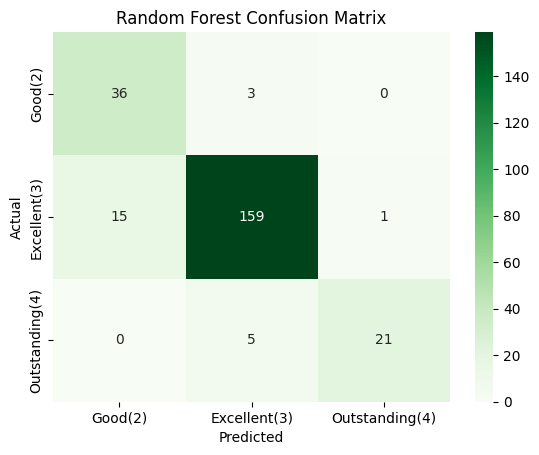

In [143]:
 # visualize confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Good(2)', 'Excellent(3)', 'Outstanding(4)'],
            yticklabels=['Good(2)', 'Excellent(3)', 'Outstanding(4)'])
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### Obervation
---
From the confusion matrix we have a total of 240 samples, (159+36+21) total of 217 corectly predicted. Against 240 we get an accuracy of 90%.




#### Tuned Random Forest

In [144]:
# tun random forest with GridSearchCV
from sklearn.model_selection import GridSearchCV

# Define parameter grid 
rf_params = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2']
}

# GridSearchCV
rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced',
                            random_state=42),
    rf_params,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

#  Fit 
rf_grid.fit(X_train_sm, y_train_sm)

# Best parameters
print("Best Random Forest parameters:")
print(rf_grid.best_params_)
print(f"Best F1 score: {rf_grid.best_score_*100:.2f}%")

# Use best estimator 
best_rf = rf_grid.best_estimator_

# Predict
y_pred_best_rf = best_rf.predict(X_test)

#  Evaluate 
print("\nTuned Random Forest Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best_rf)*100:.2f}%")
print(classification_report(y_test, y_pred_best_rf,
      target_names=['Good(2)', 'Excellent(3)', 'Outstanding(4)']))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Random Forest parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best F1 score: 94.10%

Tuned Random Forest Results:
Accuracy: 89.58%
                precision    recall  f1-score   support

       Good(2)       0.71      0.92      0.80        39
  Excellent(3)       0.95      0.90      0.93       175
Outstanding(4)       0.91      0.81      0.86        26

      accuracy                           0.90       240
     macro avg       0.86      0.88      0.86       240
  weighted avg       0.91      0.90      0.90       240



In [145]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
print(feature_importance)


Feature Importance:
                        Feature  Importance
1      EmpLastSalaryHikePercent    0.301814
0    EmpEnvironmentSatisfaction    0.265773
2       YearsSinceLastPromotion    0.133794
3  ExperienceYearsInCurrentRole    0.053321
6  ExperienceYearsAtThisCompany    0.049378
9              DistanceFromHome    0.048906
4          YearsWithCurrManager    0.046008
8    TotalWorkExperienceInYears    0.042410
5            EmpWorkLifeBalance    0.037199
7                   EmpJobLevel    0.021397


#

C:\Users\Administrator\AppData\Local\Temp\ipykernel_440\440842916.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')


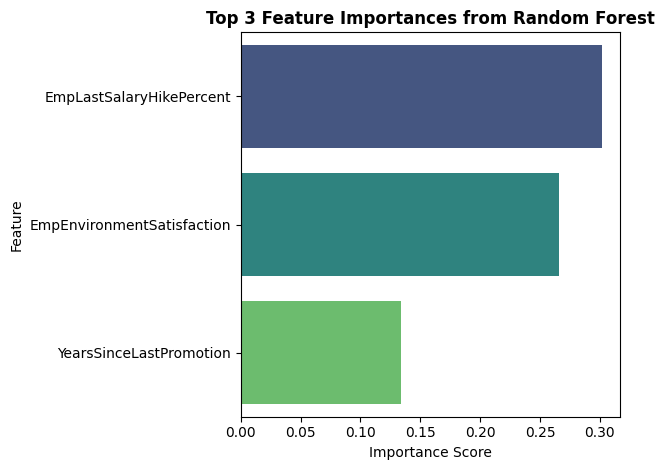

In [146]:
# visualize three most important features
top_features = feature_importance.head(3)
sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')
plt.title('Top 3 Feature Importances from Random Forest', fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

 #### Obervation
---
 **1. EmpLastSalaryHikePercent (Importance: 0.30 — Strongest Driver)**

Salary progression is the most influential factor in predicting employee performance.

Employees who receive higher salary increases consistently show better performance ratings, suggesting that compensation is a strong reinforcement mechanism for productivity and motivation.

A significant hike signals recognition and value within the organization, which often leads to improved engagement and sustained high performance. On the other hand, smaller increments may reflect lower recognition and can contribute to reduced motivation.

**2. EmpEnvironmentSatisfaction (Importance: 0.27 — High Impact)**

Work environment quality is the second most important factor influencing performance.

Employees with higher satisfaction scores tend to perform significantly better, indicating that workplace conditions—such as leadership quality, team dynamics, resources, and organizational culture—play a critical role in shaping output.

A supportive and positive environment enhances focus, engagement, and overall job effectiveness, while dissatisfaction can negatively affect productivity.

**3. YearsSinceLastPromotion (Importance: 0.13 — Moderate Influence)**

Career progression timing also has a noticeable impact on performance.

Employees who have gone longer without a promotion generally show lower performance ratings compared to those recently promoted. This suggests that stagnation in career growth can reduce motivation, engagement, and perceived career value.

Timely promotions appear to reinforce commitment and encourage consistent performance improvement

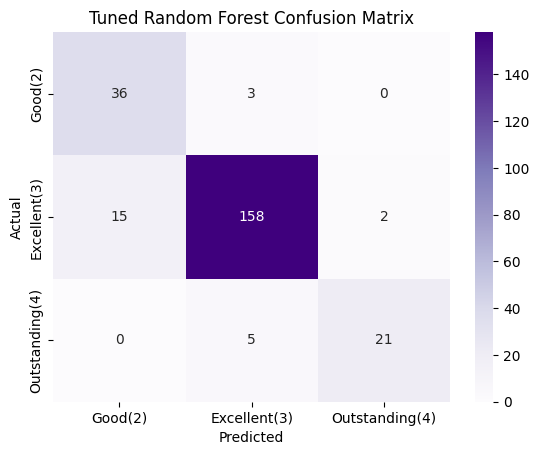

In [147]:
# visualize confusion matrix for tuned random forest
cm_best_rf = confusion_matrix(y_test, y_pred_best_rf)
sns.heatmap(cm_best_rf, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Good(2)', 'Excellent(3)', 'Outstanding(4)'],
            yticklabels=['Good(2)', 'Excellent(3)', 'Outstanding(4)'])
plt.title('Tuned Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### XGboosting Model

In [148]:
# Create model
xgb = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'
)

# Train model
xgb.fit(X_train_sm, y_train_sm)

# Predictions
y_pred_xgb = xgb.predict(X_test)

# Accuracy
xgb_acc = accuracy_score(y_test, y_pred_xgb)

print(f"Accuracy: {xgb_acc * 100:.2f}%")

# Classification report
print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=['Good(2)', 'Excellent(3)', 'Outstanding(4)']
    )
)

Accuracy: 88.33%
                precision    recall  f1-score   support

       Good(2)       0.70      0.82      0.75        39
  Excellent(3)       0.94      0.90      0.92       175
Outstanding(4)       0.85      0.85      0.85        26

      accuracy                           0.88       240
     macro avg       0.83      0.86      0.84       240
  weighted avg       0.89      0.88      0.89       240



 #### Obervation
---
Overall Accuracy for xgboost Model: 88.33% indicating strong performance.

**Class Performance**

* Good (2): Moderate class; model struggles to correctly detect all low performers (recall 0.82).
* Excellent (3): Best predicted class with very high precision (0.94) and recall (0.90).
* Outstanding (4): Good performance, but some high performers are missed (recall 0.85).


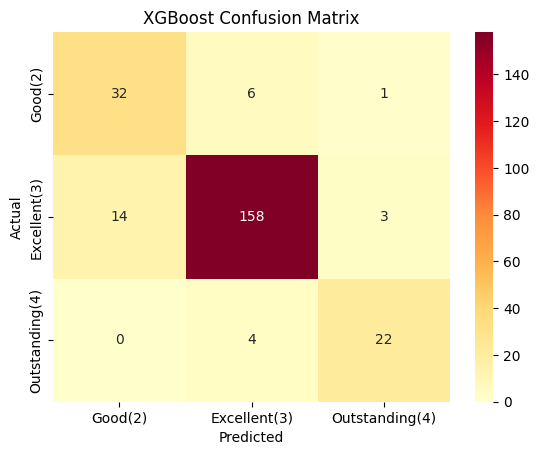

In [149]:
# visualize confusion matrix for xgboost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['Good(2)', 'Excellent(3)', 'Outstanding(4)'],
            yticklabels=['Good(2)', 'Excellent(3)', 'Outstanding(4)'])
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### Best Perforiming Model

| Model | Accuracy |
|---|---|
| Decision Tree | 84% |
| Random Forest | 90% |
| XGboost |88% |

Random Forest performs best because it combines multiple weak trees into a strong, stable model, reducing overfitting and improving generalization making it the most reliable choice for your dataset.

## 9. Model saving and deployment

In [150]:
# saving the best model (tuned random forest) using joblib
joblib.dump(rf, 'best_random_forest_model.joblib')
print("Best Random Forest model saved as 'best_random_forest_model.joblib'")

Best Random Forest model saved as 'best_random_forest_model.joblib'


## 10. Recommendation

Recommendations for Employee Performance Improvement

**1. Strengthen Fair and Performance-Based Salary Hikes**

Since Last Salary Hike % is the strongest driver of employee performance, organizations should prioritize a fair and transparent performance based compensation system. By directly linking salary increases to measurable performance outcomes, employees are more likely to stay motivated and productive. High performers should be consistently recognized with meaningful increments, while salary stagnation for high potential employees should be avoided to prevent disengagement and turnover.

**2. Improve Work Environment and Employee Experience**

This is strongly influences employee performance, organizations should prioritize building a supportive and well managed workplace. This includes improving leadership quality, strengthening teamwork, and ensuring employees have the right tools and resources to perform effectively. Clear communication channels and regular feedback mechanisms are also essential. By continuously monitoring employee satisfaction through surveys, organizations can identify concerns early and take corrective action, leading to higher engagement and improved performance outcomes.


**3. Ensure Timely Promotions and Career Growth**

Ensuring timely promotions and clear career growth opportunities is essential, as employees who experience long delays in advancement tend to show lower performance levels. Organizations should establish transparent promotion timelines and criteria so that employees understand what is required to progress. Consistently high performers should be recognized with faster career advancement to reinforce positive behavior, while efforts should be made to reduce prolonged role stagnation. This approach helps maintain motivation, engagement, and long-term commitment among employees.


**4. Use Predictive Model for HR Decision Support**

Using a predictive model such as Random Forest, which achieves high accuracy, can significantly enhance HR decision making by making it more proactive and data-driven. The model can help identify potential low performers early so that timely interventions can be applied, while also detecting high performers for recognition, retention, and reward opportunities. Additionally, it can support fair and objective decisions in promotions and appraisals by providing evidence-based insights, ultimately improving overall workforce management and organizational efficiency.

